corresponding to archive-46

In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

seed:0
seed:0
seed:1
seed:1
seed:2
seed:2
seed:3
seed:3
seed:4
seed:4
seed:5
seed:5
seed:6
seed:6
seed:7
seed:7
seed:8
seed:8
seed:9
seed:9
seed:10
seed:10
seed:11
seed:11
seed:12
seed:12
seed:13
seed:13
seed:14
seed:14
seed:15
seed:15
seed:16
seed:16
seed:17
seed:17
seed:18
seed:18
seed:19
seed:19
ub:ub1, mean:0.7954724512483125
ub:ub15, mean:0.7957465551627635
count:1/3 adult_50.pdf completed.
count:2/3 adult_v.jpg completed.
count:3/3 adult_v.jpg completed.


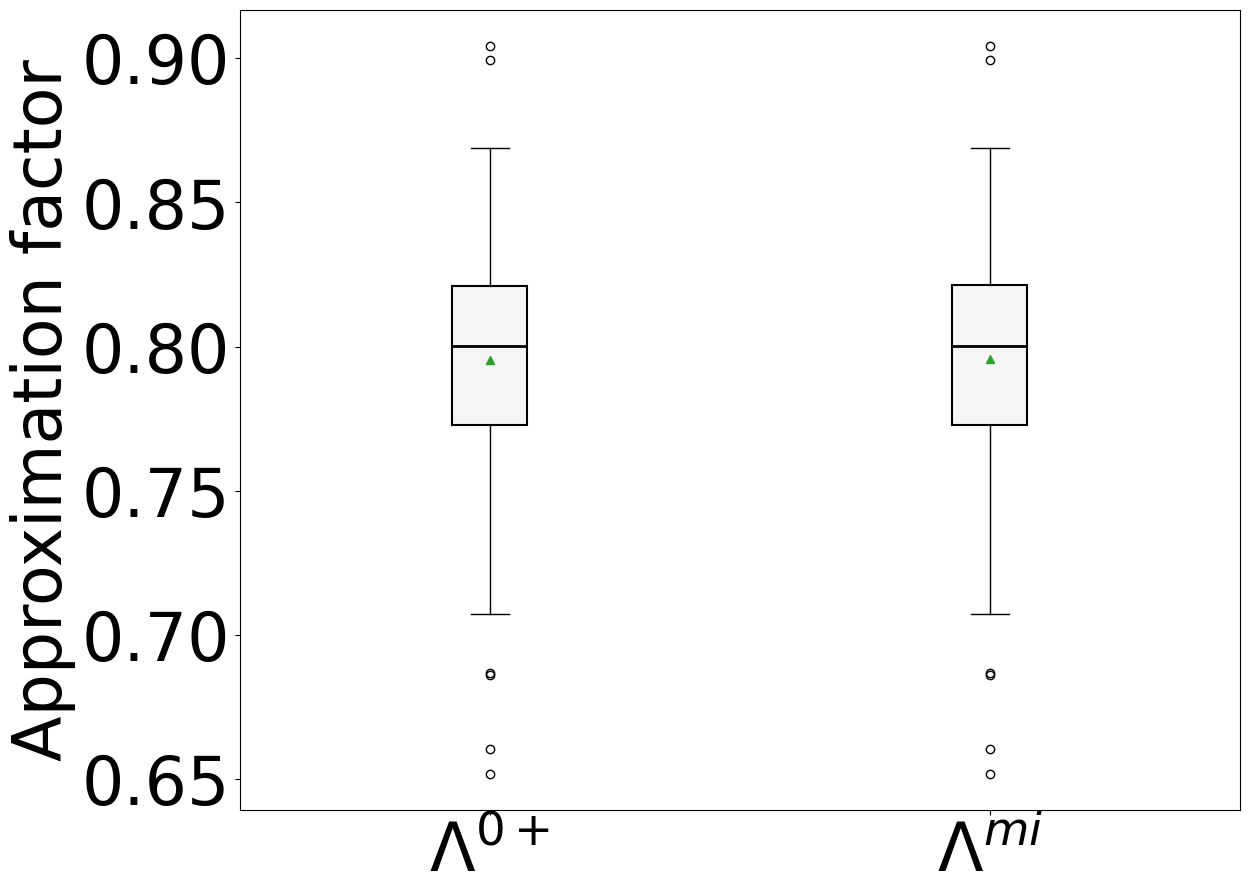

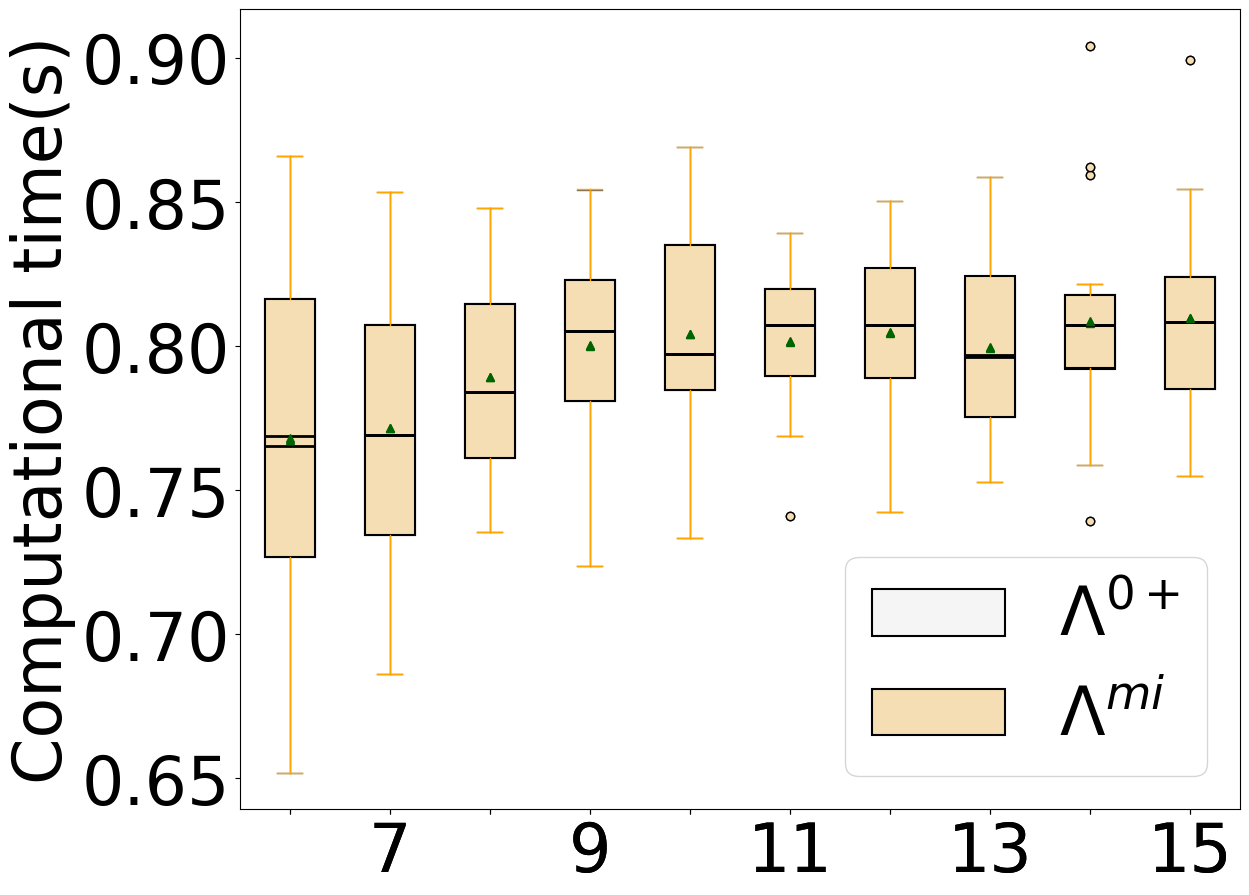

In [ ]:
t = False

def load_12_series(upper_bound: str, task_name: str, source_dir: str):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    # print(f"r:{source_dir}")
    for name in os.listdir(source_dir):
        # print(f"name:{name}")
        if not os.path.isdir(os.path.join(source_dir, name)):
            algo, up, task, budget = name.strip()[:-5].split('-')
            # algo, up, task, b = name.strip()[:-5].split('-')
            # print(f"u:{upper_bound}, t:{task_name}, up:{up}, task:{task}")
            
            if up == upper_bound and task_dict[task_name] == task:
                # print(name)
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']) )
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']) )
    res = sorted(res, key=lambda x: x[0])
    # print(res)
    X, Y, Z, W = list(zip(*res))   # change it to two columns
    return X, Y, Z, W

task_list = ['adult']

ub_list = [
    'ub1', 'ub15'
]

ub_title_dict = {
    'ub1':r'$\Lambda^{0+}$',
    'ub15':r'$\Lambda^{mi}$',
}

ub_title_list = [ub_title_dict[ub] for ub in ub_list]

archive_dir = "../result/archive-51"

result_dir = "./result_multilinear_interpolation"

n = 50
worst_case = math.log(n, math.e)
fs = 48

u_data_list = []
for ub in ub_list:
    u_data_list.append([])

seed_range = range(0, 20)
b_range = range(6, 16)

b_data_list = []
for ub in ub_list:
    temp = []
    for v in b_range:
        temp.append([])
    b_data_list.append(temp)
bti_dict = {}
for i in range(0, len(b_range)):
    b = float(b_range[i])
    bti_dict[b] = i

ub_to_draw_list = [0, 1]

count = 0
total_count = len(task_list) + len(ub_list) * len(task_list)

for task in task_list:
    for seed in seed_range:
        for ub_idx in range(0, len(ub_list)):
            # print(f"seed:{seed}")
            ub = ub_list[ub_idx]
            source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
            # print(f"seed:{seed}")
            X, Y, Z, W = load_12_series(upper_bound=ub, task_name=task, source_dir=source_dir)

            for x_idx in range(0, len(X)):
                b = X[x_idx]
                if b in b_range:
                    b_list_idx = bti_dict[b]
                    b_data_list[ub_idx][b_list_idx].append(W[x_idx])    
                    u_data_list[ub_idx].append(W[x_idx])

    # first plot
    data = u_data_list

    plt.rcParams["font.size"] = fs
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_axes([0,0,1,1])
    if t:
        ax.set_ylabel("Computational time(s)")
    else:
        ax.set_ylabel("Approximation factor")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)

    for ub_idx in range(0, len(ub_list)):
        ub = ub_list[ub_idx]
        print(f"ub:{ub}, mean:{np.mean(data[ub_idx])}")

    bp = ax.boxplot(data, patch_artist=True, showfliers=True, tick_labels=ub_title_list, showmeans=True, boxprops=box_props, medianprops=median_props)
    # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 
    
    ax.plot()

    plt.xticks(fontsize=fs) 

    for median in bp["medians"]:
        median.set_color("black")

    for box in bp["boxes"]:
        box.set_facecolor("whitesmoke")


    suffix=""
    if t:
        suffix="_T"
    else:
        suffix=""

    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.pdf"), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.jpg"), format='jpg', bbox_inches='tight')
    count = count + 1
    print(f"count:{count}/{total_count} {task}_{n}{suffix}.pdf completed.")

    # second plot

    fig = plt.figure(figsize=(10, 8))

    ax = fig.add_axes([0,0,1,1])
    # ax.set_ylabel("Approximation factor")
    ax.set_ylabel("Computational time(s)")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)
    mean_props = {"marker":"^","markerfacecolor":"darkgreen", "markeredgecolor":"darkgreen"}
    flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    whisker_props = {"color":"black"}

    color_list = ["whitesmoke","wheat", 'cornsilk']

    whisker_color_list = ["dimgray","orange",'cornsilk']
    cc = 0

    for i in ub_to_draw_list:
        data = b_data_list[i]
        ub = ub_list[i]

        flier_props["markerfacecolor"] = color_list[cc]
        whisker_props["color"] = whisker_color_list[cc]

        xtick_labels = []
        for b in b_range:
            if int(b) % 2 == 1:
                xtick_labels.append(b)
            else:
                xtick_labels.append(" ")

        bp = ax.boxplot(data,label=ub_title_dict[ub], patch_artist=True, tick_labels=xtick_labels, showmeans=True, boxprops=box_props, medianprops=median_props
                        , meanprops=mean_props, flierprops=flier_props, whiskerprops=whisker_props, capprops=whisker_props)
        # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 

        for median in bp["medians"]:
            median.set_color("black")
        for box in bp["boxes"]:
            box.set_facecolor(color_list[cc])

        cc = cc + 1

        plt.legend()

        plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}.jpg"), format='jpg', bbox_inches='tight')
        count = count + 1
        print(f"count:{count}/{total_count} {task}_v.jpg completed.")
    

youtube: 
ub:ub1r, mean:0.9687221290458079
ub:ub1ru, mean:0.9687221474233066
facebook:
ub:ub1r, mean:0.9795020920575624
ub:ub1ru, mean:0.9795020599495742
adult:
ub:ub1r, mean:0.9867065009829467
ub:ub1ru, mean:0.9867065010591107
caltech:
ub:ub1r, mean:0.9683247650560657
ub:ub1ru, mean:0.9683247650202066